# MalthusJAX Fitness Parity Analysis
**Source:** `Results_DAH02/fitness_parity/` (19 experiments, 30 seeds each)  
**Machine:** DAH2 — Intel Xeon Platinum 8570, 224 cores @ 4.0 GHz  
**Problem:** BBOB Sphere, pop=200, d=10, 100 generations

This workbook inspects **fitness correctness** rather than performance.  All
configurations now start from a *canonical population* derived from each seed
and include an evosax SimpleGA run as the golden-standard baseline.  The
comparison therefore isolates operator effects instead of random initial
variation.

Analyses cover injection-mode operators (standard vs injection) and
key-derivation strategies (SPLIT vs FOLD).

All plots use 95 % confidence intervals (CI) computed from per-seed runs.

## 1. Load All Experiments
*Note: canonical population + evosax baseline have already been baked into the
results, so each experiment row corresponds to MalthusJAX or evosax starting
from the same initial genes.*

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sp_stats

# ── aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE_MODE = {"standard": "#4878CF", "injection": "#D65F5F"}
PALETTE_KD   = {"split": "#4878CF", "fold_in": "#6ACC65"}
FIG_DIR = Path("artifacts/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── load all summary.json files ─────────────────────────────────────────────
DATA_DIR = Path("../Results_DAH02/fitness_parity")
summary_files = sorted(DATA_DIR.glob("*/summary.json"))

# Parse experiment name into structured fields
_NAME_RE = re.compile(
    r"mjx_(?P<problem>\w+)_p(?P<pop>\d+)_d(?P<dims>\d+)"
    r"_(?P<mode>std|inj)_(?P<crossover>\w+)x_(?P<mutation>\w+)m"
    r"_(?P<key_deriv>.+)"
)

all_runs = []          # one row per (experiment, seed)
all_summaries = []     # one row per experiment (aggregated)

for sf in summary_files:
    exp_name = sf.parent.name
    m = _NAME_RE.match(exp_name)
    if not m:
        print(f"WARN: could not parse {exp_name}")
        continue
    meta = m.groupdict()
    meta["pop"] = int(meta["pop"])
    meta["dims"] = int(meta["dims"])
    mode_label = "injection" if meta["mode"] == "inj" else "standard"

    with open(sf) as f:
        data = json.load(f)

    for run in data["runs"]:
        row = {
            "experiment": exp_name,
            "mode": mode_label,
            "crossover": meta["crossover"],
            "mutation": meta["mutation"],
            "key_derivation": meta["key_deriv"],
            "seed": run["seed"],
            "status": run["status"],
            **run["metrics"],
        }
        if run.get("timings"):
            row["t_init"] = run["timings"].get("initialization")
            row["t_evo"]  = run["timings"].get("evolution")
        all_runs.append(row)

df = pd.DataFrame(all_runs)
n_exp = df["experiment"].nunique()
n_seeds = df.groupby("experiment")["seed"].nunique().iloc[0]
print(f"Loaded {n_exp} experiments × {n_seeds} seeds = {len(df)} total runs")
print(f"Columns: {list(df.columns)}")
df.head(4)

WARN: could not parse evosax_sphere_p200_d10
Loaded 19 experiments × 30 seeds = 570 total runs
Columns: ['experiment', 'mode', 'crossover', 'mutation', 'key_derivation', 'seed', 'status', 'best_fitness', 'start_best_fitness', 'end_best_fitness', 'delta_best', 'final_generation', 'total_evaluations', 't_init', 't_evo']


,experiment,mode,crossover,mutation,key_derivation,seed,status,best_fitness,start_best_fitness,end_best_fitness,delta_best,final_generation,total_evaluations,t_init,t_evo
0,mjx_sphere_p200_d10_inj_binomialx_gaussianm_fo...,injection,binomial,gaussian,fold_in,0,success,-193.854721,-180.030670,-193.854721,13.824051,99.0,20000.0,0.315021,1.838286
1,mjx_sphere_p200_d10_inj_binomialx_gaussianm_fo...,injection,binomial,gaussian,fold_in,1,success,-193.856461,-177.849884,-193.856461,16.006577,99.0,20000.0,0.257227,1.747327
2,mjx_sphere_p200_d10_inj_binomialx_gaussianm_fo...,injection,binomial,gaussian,fold_in,2,success,-193.856110,-163.346603,-193.856110,30.509506,99.0,20000.0,0.259159,1.750756
3,mjx_sphere_p200_d10_inj_binomialx_gaussianm_fo...,injection,binomial,gaussian,fold_in,3,success,-193.856598,-180.497940,-193.856598,13.358658,99.0,20000.0,0.320326,1.930809


In [2]:
# ── helper: 95% confidence interval ─────────────────────────────────────────
def ci95(series):
    """Return (mean, lo, hi) for a 95% CI using the t-distribution."""
    n = len(series)
    mean = series.mean()
    if n < 2:
        return mean, mean, mean
    se = series.std(ddof=1) / np.sqrt(n)
    t_crit = sp_stats.t.ppf(0.975, df=n - 1)
    return mean, mean - t_crit * se, mean + t_crit * se


def agg_ci(group, col="best_fitness"):
    """Aggregate a group into mean + CI bounds."""
    vals = group[col]
    mean, lo, hi = ci95(vals)
    return pd.Series({
        "mean": mean, "ci_lo": lo, "ci_hi": hi,
        "std": vals.std(), "n": len(vals),
    })


# ── also load convergence histories from CSVs ──────────────────────────────
hist_frames = []
for sf in summary_files:
    exp_name = sf.parent.name
    csv_path = sf.parent / "histories_combined.csv"
    if not csv_path.exists():
        continue
    m = _NAME_RE.match(exp_name)
    if not m:
        continue
    meta = m.groupdict()
    mode_label = "injection" if meta["mode"] == "inj" else "standard"
    hdf = pd.read_csv(csv_path)
    hdf["experiment"] = exp_name
    hdf["mode"] = mode_label
    hdf["crossover"] = meta["crossover"]
    hdf["mutation"] = meta["mutation"]
    hdf["key_derivation"] = meta["key_deriv"]
    hist_frames.append(hdf)

hist = pd.concat(hist_frames, ignore_index=True)
print(f"Convergence history: {len(hist)} rows, {hist['experiment'].nunique()} experiments")
hist.head(3)

Convergence history: 57000 rows, 19 experiments


,seed,best_fitness,generation,mean_fitness,experiment,mode,crossover,mutation,key_derivation
0,0,-180.030670,1,-79.368805,mjx_sphere_p200_d10_inj_binomialx_gaussianm_fo...,injection,binomial,gaussian,fold_in
1,0,-182.616501,2,-103.171562,mjx_sphere_p200_d10_inj_binomialx_gaussianm_fo...,injection,binomial,gaussian,fold_in
2,0,-183.067261,3,-121.652504,mjx_sphere_p200_d10_inj_binomialx_gaussianm_fo...,injection,binomial,gaussian,fold_in


## 2. Summary Table — All Experiments
Mean best fitness ± 95 % CI across seeds, grouped by operator configuration.

In [3]:
summary = (
    df.groupby(["crossover", "mutation", "mode", "key_derivation"])
    .apply(lambda g: agg_ci(g, "best_fitness"), include_groups=False)
    .reset_index()
)
summary["label"] = (
    summary["crossover"] + " × " + summary["mutation"]
    + " [" + summary["mode"] + ", " + summary["key_derivation"] + "]"
)
summary["ci_width"] = summary["ci_hi"] - summary["ci_lo"]

# Show table sorted by mean best fitness (lower = better for minimisation)
display_cols = ["label", "mean", "ci_lo", "ci_hi", "std", "n"]
summary.sort_values("mean")[display_cols].style.format({
    "mean": "{:.4f}", "ci_lo": "{:.4f}", "ci_hi": "{:.4f}",
    "std": "{:.4f}", "n": "{:.0f}",
}).set_caption("Best fitness across seeds (95 % CI)")

,label,mean,ci_lo,ci_hi,std,n
3,"blend × gaussian [injection, fold_in]",-193.8567,-193.8567,-193.8567,0.0000,30
4,"blend × gaussian [injection, split]",-193.8567,-193.8567,-193.8567,0.0000,30
5,"blend × gaussian [standard, split]",-193.8567,-193.8567,-193.8567,0.0000,30
15,"uniform × gaussian [standard, split]",-193.8567,-193.8567,-193.8567,0.0000,30
14,"uniform × gaussian [standard, fold_in]",-193.8567,-193.8567,-193.8567,0.0000,30
8,"sbx × gaussian [standard, split]",-193.8567,-193.8567,-193.8567,0.0000,30
12,"uniform × gaussian [injection, fold_in]",-193.8567,-193.8567,-193.8567,0.0000,30
13,"uniform × gaussian [injection, split]",-193.8567,-193.8567,-193.8567,0.0000,30
6,"sbx × gaussian [injection, fold_in]",-193.8567,-193.8567,-193.8566,0.0000,30
7,"sbx × gaussian [injection, split]",-193.8567,-193.8567,-193.8566,0.0000,30


## 3. Crossover Parity — Standard vs Injection
Best fitness comparison across crossover types. Each bar shows the mean over seeds with a 95 % CI error bar.
If injection mode is correct, bars should overlap within confidence intervals.

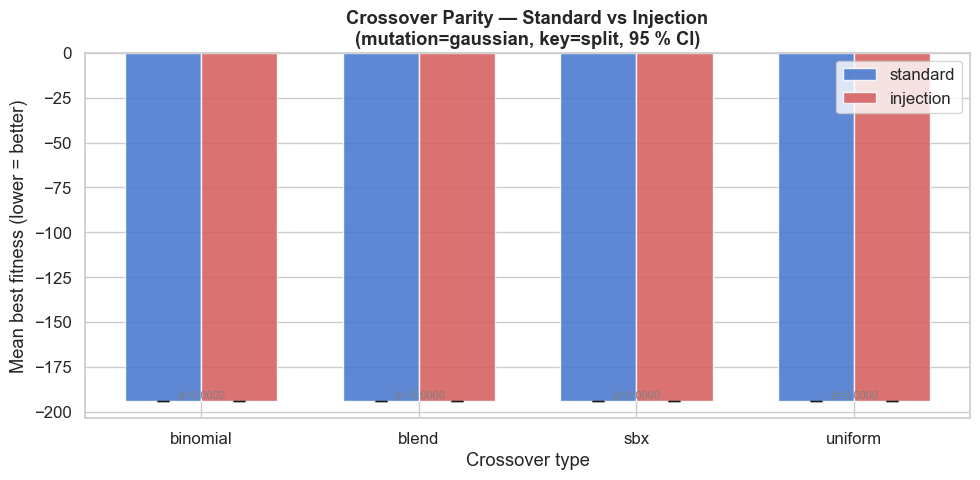

In [4]:
# Filter: crossover parity tests (mutation=gaussian, key_derivation=split)
cross_df = df[(df["mutation"] == "gaussian") & (df["key_derivation"] == "split")].copy()
cross_types = sorted(cross_df["crossover"].unique())
modes = ["standard", "injection"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cross_types))
w = 0.35

for i, mode in enumerate(modes):
    means, ci_los, ci_his = [], [], []
    for ct in cross_types:
        sub = cross_df[(cross_df["crossover"] == ct) & (cross_df["mode"] == mode)]
        if len(sub) == 0:
            means.append(np.nan); ci_los.append(0); ci_his.append(0)
            continue
        mean, lo, hi = ci95(sub["best_fitness"])
        means.append(mean)
        ci_los.append(mean - lo)
        ci_his.append(hi - mean)

    ax.bar(
        x + i * w, means, w, label=mode, color=PALETTE_MODE[mode],
        yerr=[ci_los, ci_his], capsize=4, alpha=0.88, edgecolor="white",
    )

ax.set_xticks(x + w / 2)
ax.set_xticklabels(cross_types)
ax.set_xlabel("Crossover type")
ax.set_ylabel("Mean best fitness (lower = better)")
ax.set_title("Crossover Parity — Standard vs Injection\n(mutation=gaussian, key=split, 95 % CI)",
             fontweight="bold")
ax.legend()

# Annotate parity gap
for j, ct in enumerate(cross_types):
    std_val = cross_df[(cross_df["crossover"] == ct) & (cross_df["mode"] == "standard")]["best_fitness"].mean()
    inj_val = cross_df[(cross_df["crossover"] == ct) & (cross_df["mode"] == "injection")]["best_fitness"].mean()
    if not (np.isnan(std_val) or np.isnan(inj_val)):
        gap = inj_val - std_val
        ax.text(j + w / 2, max(std_val, inj_val) + 0.01, f"Δ={gap:.4f}",
                ha="center", va="bottom", fontsize=8, color="grey")

fig.tight_layout()
fig.savefig(FIG_DIR / "fp_01_crossover_parity.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Mutation Parity — Standard vs Injection
Same layout as above but varying mutation type (crossover=uniform, key=split).

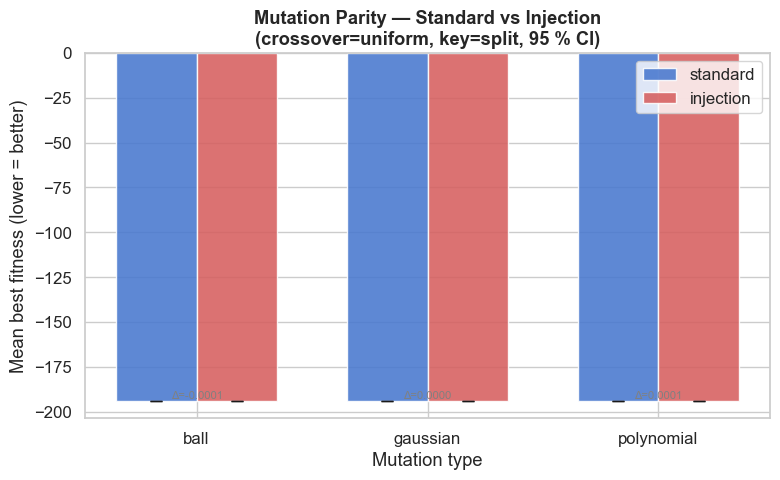

In [5]:
# Filter: mutation parity tests (crossover=uniform, key_derivation=split)
mut_df = df[(df["crossover"] == "uniform") & (df["key_derivation"] == "split")].copy()
mut_types = sorted(mut_df["mutation"].unique())

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(mut_types))
w = 0.35

for i, mode in enumerate(modes):
    means, ci_los, ci_his = [], [], []
    for mt in mut_types:
        sub = mut_df[(mut_df["mutation"] == mt) & (mut_df["mode"] == mode)]
        if len(sub) == 0:
            means.append(np.nan); ci_los.append(0); ci_his.append(0)
            continue
        mean, lo, hi = ci95(sub["best_fitness"])
        means.append(mean)
        ci_los.append(mean - lo)
        ci_his.append(hi - mean)

    ax.bar(
        x + i * w, means, w, label=mode, color=PALETTE_MODE[mode],
        yerr=[ci_los, ci_his], capsize=4, alpha=0.88, edgecolor="white",
    )

ax.set_xticks(x + w / 2)
ax.set_xticklabels(mut_types)
ax.set_xlabel("Mutation type")
ax.set_ylabel("Mean best fitness (lower = better)")
ax.set_title("Mutation Parity — Standard vs Injection\n(crossover=uniform, key=split, 95 % CI)",
             fontweight="bold")
ax.legend()

for j, mt in enumerate(mut_types):
    std_val = mut_df[(mut_df["mutation"] == mt) & (mut_df["mode"] == "standard")]["best_fitness"].mean()
    inj_val = mut_df[(mut_df["mutation"] == mt) & (mut_df["mode"] == "injection")]["best_fitness"].mean()
    if not (np.isnan(std_val) or np.isnan(inj_val)):
        gap = inj_val - std_val
        ax.text(j + w / 2, max(std_val, inj_val) + 0.01, f"Δ={gap:.4f}",
                ha="center", va="bottom", fontsize=8, color="grey")

fig.tight_layout()
fig.savefig(FIG_DIR / "fp_02_mutation_parity.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Key Derivation Parity — SPLIT vs FOLD
Compares `KeyDerivationStrategy.SPLIT` (sequential `jax.random.split`) against `FOLD` (parallel `jax.random.fold_in`).
If both strategies are correct the CIs should overlap.

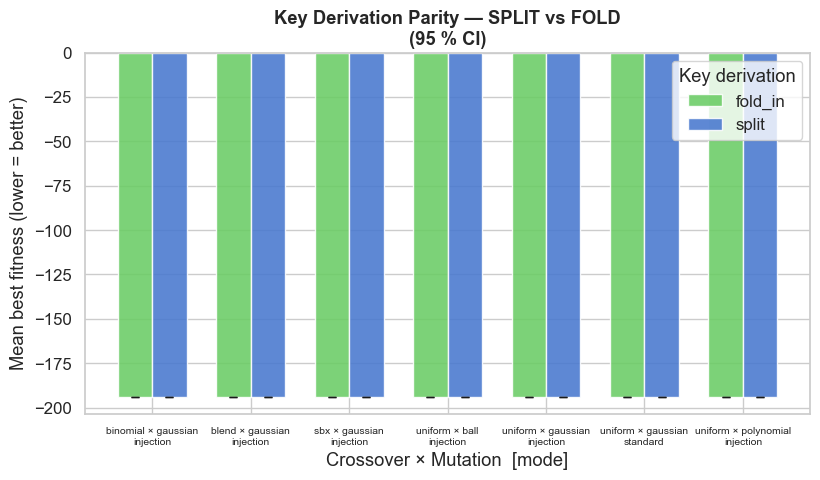

In [6]:
# Key derivation parity — group by (crossover, mutation, mode) and split vs fold_in
kd_df = df.copy()
kd_types = sorted(kd_df["key_derivation"].unique())

# Build a grouped comparison: each "config" is crossover×mutation×mode
kd_df["config"] = kd_df["crossover"] + " × " + kd_df["mutation"] + "\n" + kd_df["mode"]
configs = sorted(kd_df["config"].unique())

# Only keep configs that have BOTH split and fold_in
configs_both = [
    c for c in configs
    if all(
        len(kd_df[(kd_df["config"] == c) & (kd_df["key_derivation"] == kd)]) > 0
        for kd in kd_types
    )
]

fig, ax = plt.subplots(figsize=(max(8, len(configs_both) * 1.2), 5))
x = np.arange(len(configs_both))
w = 0.35

for i, kd in enumerate(kd_types):
    means, ci_los, ci_his = [], [], []
    for cfg in configs_both:
        sub = kd_df[(kd_df["config"] == cfg) & (kd_df["key_derivation"] == kd)]
        mean, lo, hi = ci95(sub["best_fitness"])
        means.append(mean)
        ci_los.append(mean - lo)
        ci_his.append(hi - mean)

    ax.bar(
        x + i * w, means, w, label=kd, color=PALETTE_KD.get(kd, None),
        yerr=[ci_los, ci_his], capsize=3, alpha=0.88, edgecolor="white",
    )

ax.set_xticks(x + w / 2)
ax.set_xticklabels(configs_both, fontsize=7.5)
ax.set_xlabel("Crossover × Mutation  [mode]")
ax.set_ylabel("Mean best fitness (lower = better)")
ax.set_title("Key Derivation Parity — SPLIT vs FOLD\n(95 % CI)", fontweight="bold")
ax.legend(title="Key derivation")
fig.tight_layout()
fig.savefig(FIG_DIR / "fp_03_key_derivation_parity.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Convergence Curves — Standard vs Injection
Generation-by-generation `best_fitness` averaged across seeds with a shaded 95 % CI band.
One subplot per crossover type (mutation=gaussian, key=split).

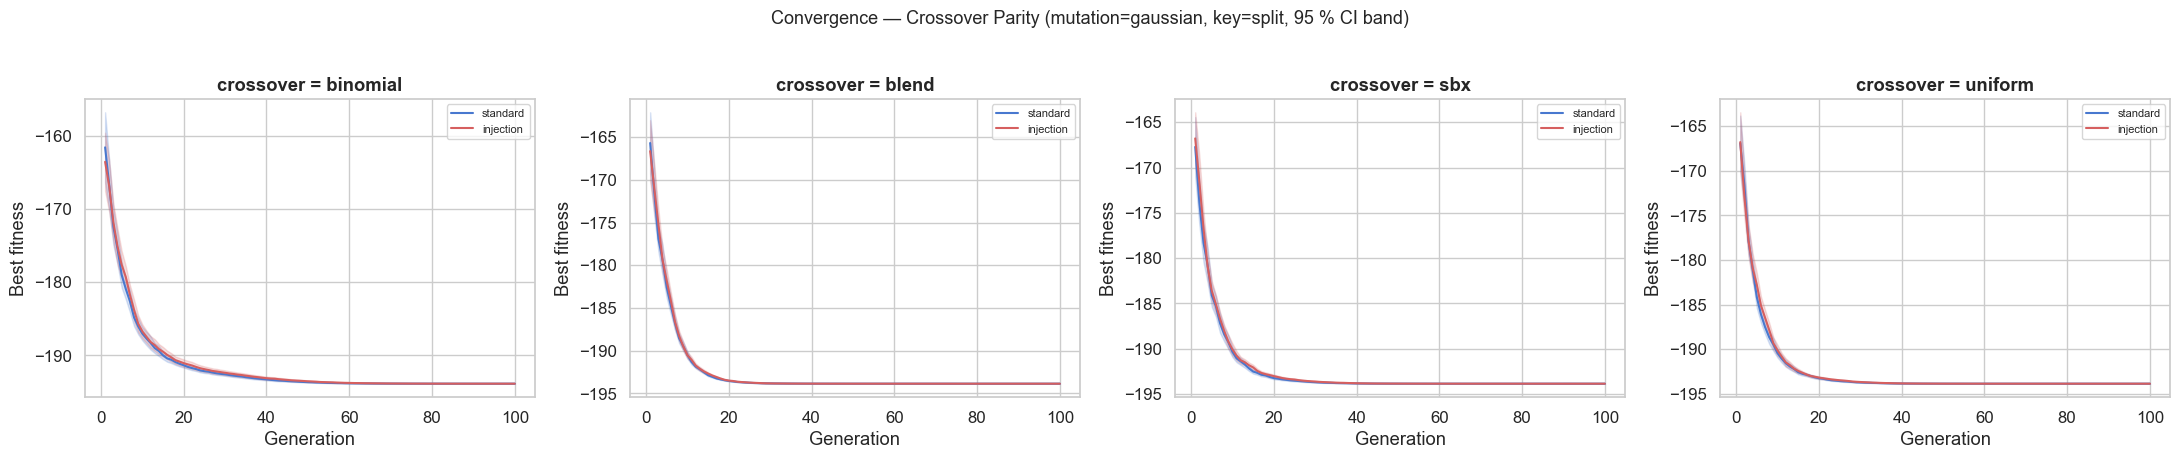

In [7]:
# Convergence curves: crossover parity (mutation=gaussian, key=split)
conv_cross = hist[(hist["mutation"] == "gaussian") & (hist["key_derivation"] == "split")].copy()
cross_types = sorted(conv_cross["crossover"].unique())

ncols = min(len(cross_types), 4)
nrows = int(np.ceil(len(cross_types) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for idx, ct in enumerate(cross_types):
    ax = axes_flat[idx]
    sub = conv_cross[conv_cross["crossover"] == ct]

    for mode, color in PALETTE_MODE.items():
        msub = sub[sub["mode"] == mode]
        if msub.empty:
            continue
        # Aggregate per generation across seeds
        gen_agg = msub.groupby("generation")["best_fitness"].agg(["mean", "std", "count"]).reset_index()
        gen_agg["se"] = gen_agg["std"] / np.sqrt(gen_agg["count"])
        # t-distribution critical value
        gen_agg["t_crit"] = gen_agg["count"].apply(lambda n: sp_stats.t.ppf(0.975, max(n - 1, 1)))
        gen_agg["ci_lo"] = gen_agg["mean"] - gen_agg["t_crit"] * gen_agg["se"]
        gen_agg["ci_hi"] = gen_agg["mean"] + gen_agg["t_crit"] * gen_agg["se"]

        ax.plot(gen_agg["generation"], gen_agg["mean"], color=color, linewidth=1.5, label=mode)
        ax.fill_between(gen_agg["generation"], gen_agg["ci_lo"], gen_agg["ci_hi"],
                        color=color, alpha=0.2)

    ax.set_title(f"crossover = {ct}", fontweight="bold")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best fitness")
    ax.legend(fontsize=8)

# Hide unused subplots
for idx in range(len(cross_types), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle("Convergence — Crossover Parity (mutation=gaussian, key=split, 95 % CI band)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fp_04_convergence_crossover.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Convergence Curves — Mutation Parity
Same as above but varying mutation type (crossover=uniform, key=split).

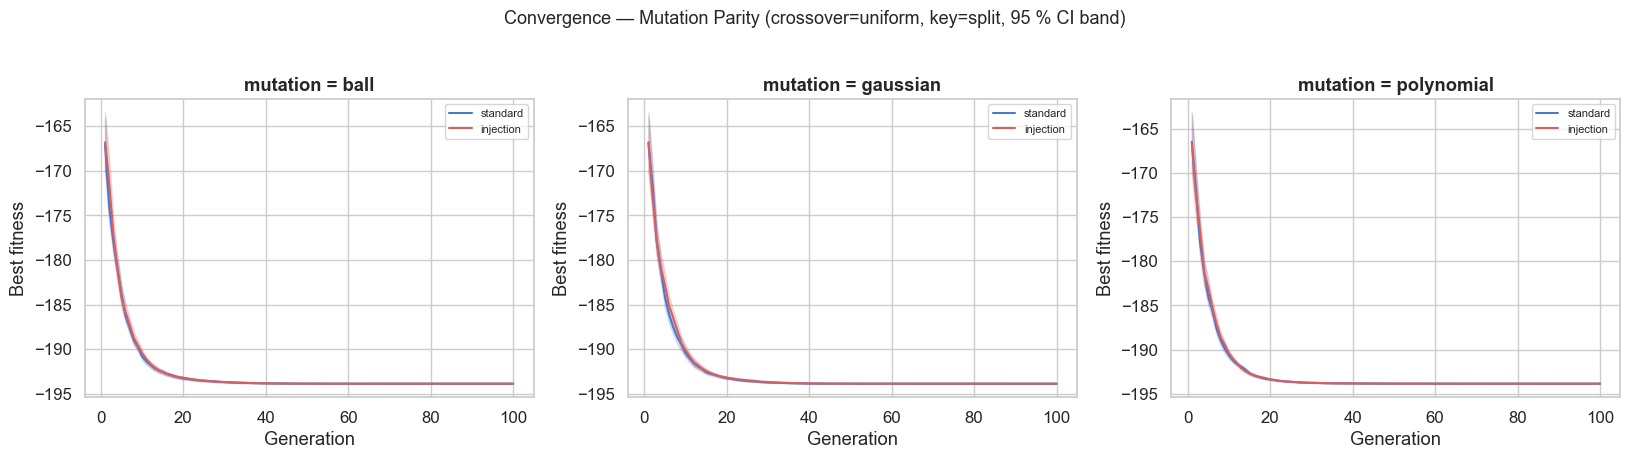

In [8]:
# Convergence curves: mutation parity (crossover=uniform, key=split)
conv_mut = hist[(hist["crossover"] == "uniform") & (hist["key_derivation"] == "split")].copy()
mut_types = sorted(conv_mut["mutation"].unique())

ncols = min(len(mut_types), 3)
nrows = int(np.ceil(len(mut_types) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for idx, mt in enumerate(mut_types):
    ax = axes_flat[idx]
    sub = conv_mut[conv_mut["mutation"] == mt]

    for mode, color in PALETTE_MODE.items():
        msub = sub[sub["mode"] == mode]
        if msub.empty:
            continue
        gen_agg = msub.groupby("generation")["best_fitness"].agg(["mean", "std", "count"]).reset_index()
        gen_agg["se"] = gen_agg["std"] / np.sqrt(gen_agg["count"])
        gen_agg["t_crit"] = gen_agg["count"].apply(lambda n: sp_stats.t.ppf(0.975, max(n - 1, 1)))
        gen_agg["ci_lo"] = gen_agg["mean"] - gen_agg["t_crit"] * gen_agg["se"]
        gen_agg["ci_hi"] = gen_agg["mean"] + gen_agg["t_crit"] * gen_agg["se"]

        ax.plot(gen_agg["generation"], gen_agg["mean"], color=color, linewidth=1.5, label=mode)
        ax.fill_between(gen_agg["generation"], gen_agg["ci_lo"], gen_agg["ci_hi"],
                        color=color, alpha=0.2)

    ax.set_title(f"mutation = {mt}", fontweight="bold")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best fitness")
    ax.legend(fontsize=8)

for idx in range(len(mut_types), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle("Convergence — Mutation Parity (crossover=uniform, key=split, 95 % CI band)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fp_05_convergence_mutation.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Convergence Curves — Key Derivation (SPLIT vs FOLD)
Shaded convergence for injection-mode uniform × gaussian under both entropy strategies.

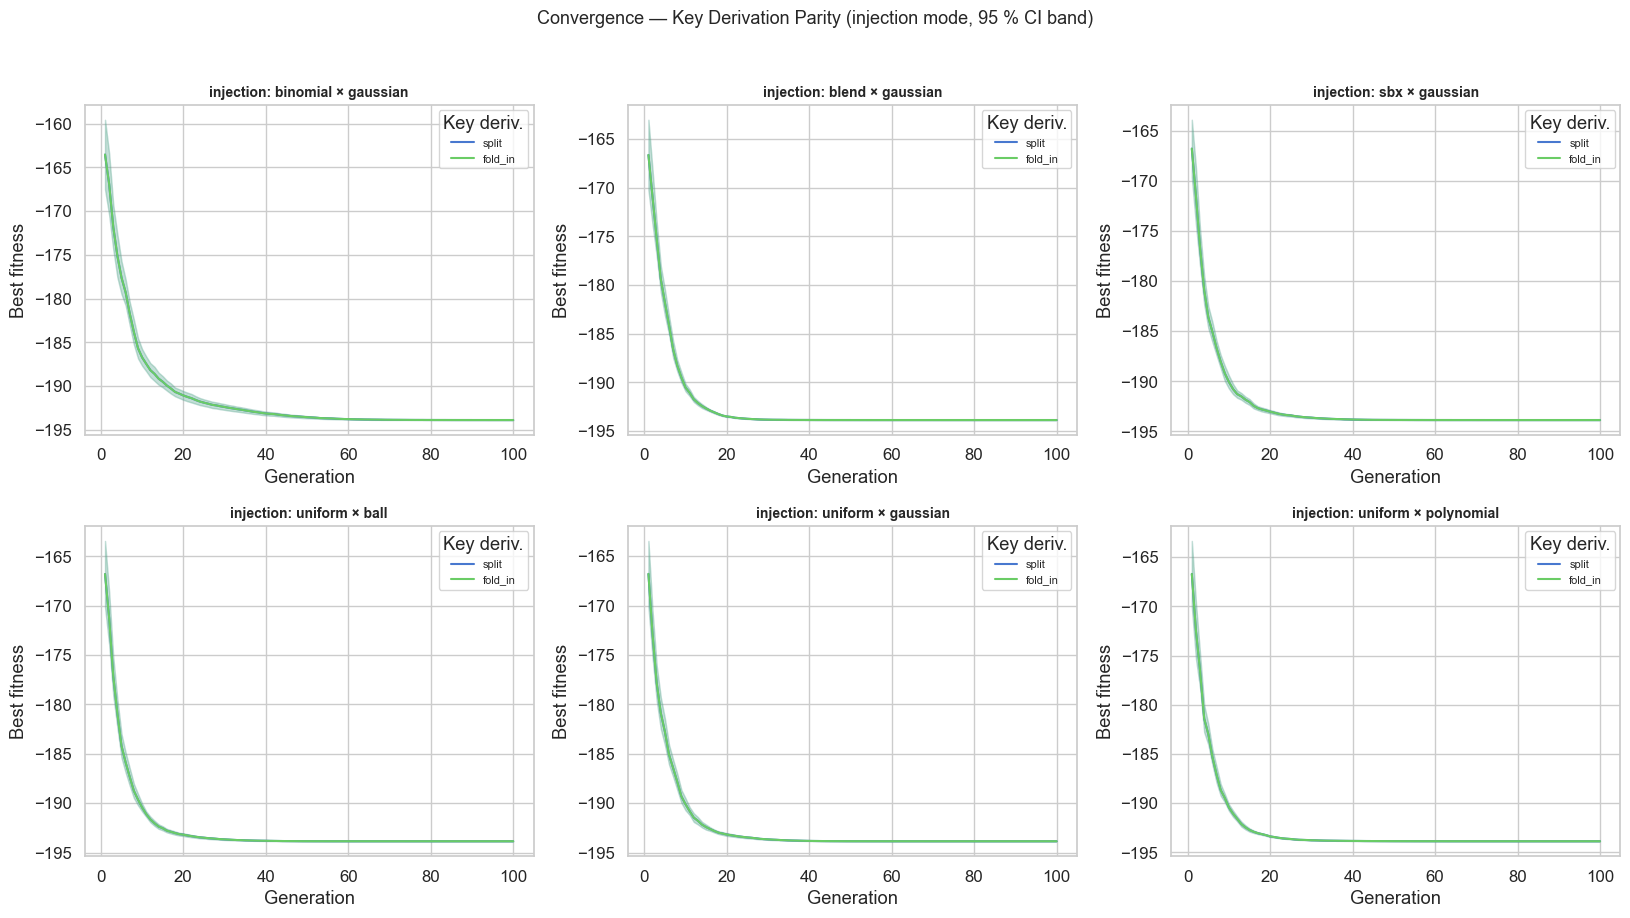

In [9]:
# Convergence curves: key derivation parity
# Show all injection-mode experiments that have both split and fold_in
conv_kd = hist[hist["mode"] == "injection"].copy()
conv_kd["config"] = conv_kd["crossover"] + " × " + conv_kd["mutation"]
kd_configs = sorted(conv_kd["config"].unique())

# Keep only configs that have both key derivations
kd_configs_both = [
    c for c in kd_configs
    if all(
        len(conv_kd[(conv_kd["config"] == c) & (conv_kd["key_derivation"] == kd)]) > 0
        for kd in ["split", "fold_in"]
    )
]

ncols = min(len(kd_configs_both), 3)
nrows = int(np.ceil(len(kd_configs_both) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for idx, cfg in enumerate(kd_configs_both):
    ax = axes_flat[idx]
    sub = conv_kd[conv_kd["config"] == cfg]

    for kd, color in PALETTE_KD.items():
        ksub = sub[sub["key_derivation"] == kd]
        if ksub.empty:
            continue
        gen_agg = ksub.groupby("generation")["best_fitness"].agg(["mean", "std", "count"]).reset_index()
        gen_agg["se"] = gen_agg["std"] / np.sqrt(gen_agg["count"])
        gen_agg["t_crit"] = gen_agg["count"].apply(lambda n: sp_stats.t.ppf(0.975, max(n - 1, 1)))
        gen_agg["ci_lo"] = gen_agg["mean"] - gen_agg["t_crit"] * gen_agg["se"]
        gen_agg["ci_hi"] = gen_agg["mean"] + gen_agg["t_crit"] * gen_agg["se"]

        ax.plot(gen_agg["generation"], gen_agg["mean"], color=color, linewidth=1.5, label=kd)
        ax.fill_between(gen_agg["generation"], gen_agg["ci_lo"], gen_agg["ci_hi"],
                        color=color, alpha=0.2)

    ax.set_title(f"injection: {cfg}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best fitness")
    ax.legend(fontsize=8, title="Key deriv.")

for idx in range(len(kd_configs_both), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle("Convergence — Key Derivation Parity (injection mode, 95 % CI band)",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fp_06_convergence_key_derivation.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Improvement (Δ best) — Dot-plot with 95 % CI
How much fitness improved from generation 1 to generation 100 (`delta_best = start − end`).
Positive values mean evolution improved; the larger the better.

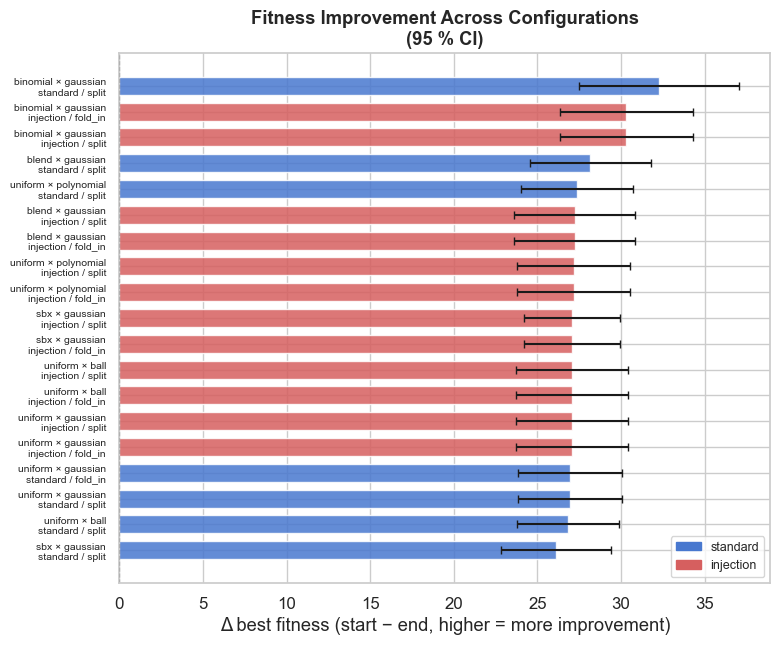

In [10]:
# Delta best dot-plot with 95% CI
delta_agg = (
    df.groupby(["crossover", "mutation", "mode", "key_derivation"])
    .apply(lambda g: agg_ci(g, "delta_best"), include_groups=False)
    .reset_index()
)
delta_agg["label"] = (
    delta_agg["crossover"] + " × " + delta_agg["mutation"]
    + "\n" + delta_agg["mode"] + " / " + delta_agg["key_derivation"]
)
delta_agg = delta_agg.sort_values("mean", ascending=True).reset_index(drop=True)

# Colour by mode
colours = [PALETTE_MODE[m] for m in delta_agg["mode"]]

fig, ax = plt.subplots(figsize=(8, max(5, len(delta_agg) * 0.35)))
y = np.arange(len(delta_agg))
xerr_lo = delta_agg["mean"] - delta_agg["ci_lo"]
xerr_hi = delta_agg["ci_hi"] - delta_agg["mean"]

ax.barh(y, delta_agg["mean"], xerr=[xerr_lo, xerr_hi],
        color=colours, capsize=3, alpha=0.85, edgecolor="white", height=0.7)
ax.set_yticks(y)
ax.set_yticklabels(delta_agg["label"], fontsize=7.5)
ax.set_xlabel("Δ best fitness (start − end, higher = more improvement)")
ax.set_title("Fitness Improvement Across Configurations\n(95 % CI)", fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=PALETTE_MODE[m], label=m) for m in modes]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "fp_07_delta_best_dotplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Per-Seed Distribution — Swarm + Box Plot
Visualises the per-seed spread of final best fitness for every configuration.
Useful for spotting outlier seeds and confirming that variance is similar across modes.

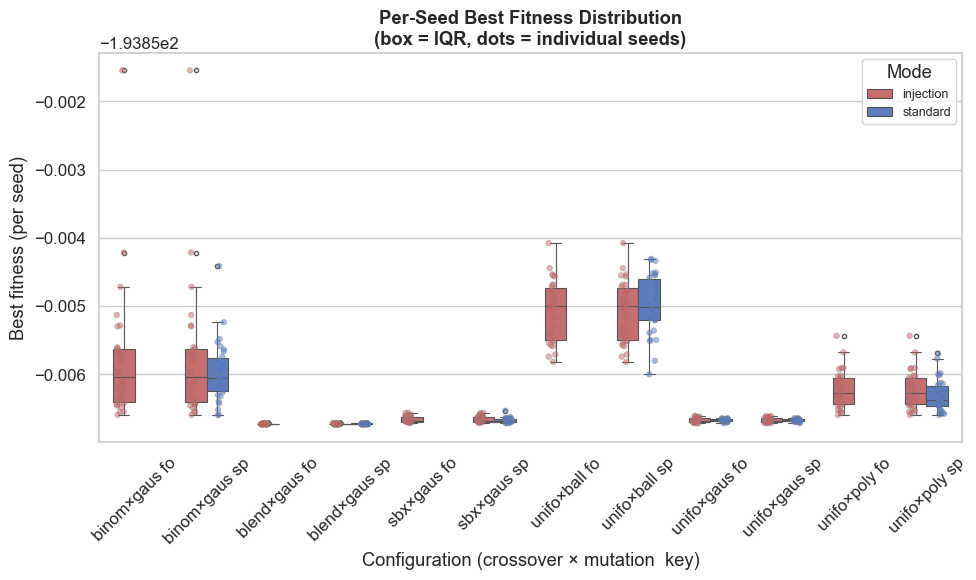

In [11]:
# Swarm + box plot of per-seed best fitness
df["config_short"] = (
    df["crossover"].str[:5] + "×" + df["mutation"].str[:4]
    + " " + df["key_derivation"].str[:2]
)

fig, ax = plt.subplots(figsize=(max(10, df["config_short"].nunique() * 0.7), 6))
sns.boxplot(
    data=df, x="config_short", y="best_fitness", hue="mode",
    palette=PALETTE_MODE, width=0.6, linewidth=0.8,
    fliersize=3, ax=ax,
)
sns.stripplot(
    data=df, x="config_short", y="best_fitness", hue="mode",
    palette=PALETTE_MODE, dodge=True, size=4, alpha=0.5,
    linewidth=0.5, edgecolor="grey", ax=ax, legend=False,
)
ax.set_xlabel("Configuration (crossover × mutation  key)")
ax.set_ylabel("Best fitness (per seed)")
ax.set_title("Per-Seed Best Fitness Distribution\n(box = IQR, dots = individual seeds)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Mode", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "fp_08_seed_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Parity Heatmap — Absolute Gap (Standard − Injection)
A heatmap showing the absolute difference in mean best fitness between standard and injection modes.  
Values near zero confirm parity; large values would indicate a bug in the injection implementation.

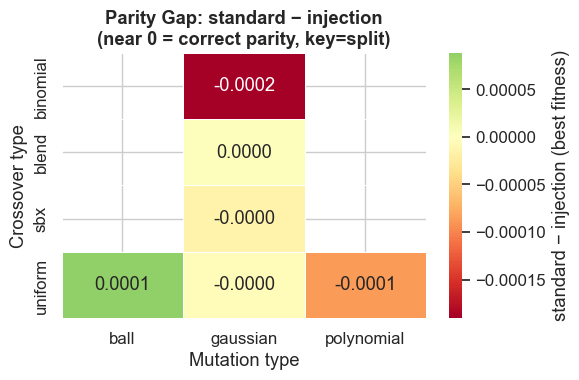

In [12]:
# Parity heatmap: |mean_standard - mean_injection|
# Only look at key_derivation=split for the crossover×mutation grid
parity_df = df[df["key_derivation"] == "split"].copy()
means = (
    parity_df.groupby(["crossover", "mutation", "mode"])["best_fitness"]
    .mean()
    .unstack("mode")
)

if "standard" in means.columns and "injection" in means.columns:
    gap = (means["standard"] - means["injection"]).unstack("mutation")

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(
        gap, annot=True, fmt=".4f", cmap="RdYlGn", center=0,
        linewidths=0.5, ax=ax,
        cbar_kws={"label": "standard − injection (best fitness)"},
    )
    ax.set_title("Parity Gap: standard − injection\n(near 0 = correct parity, key=split)",
                 fontweight="bold")
    ax.set_xlabel("Mutation type")
    ax.set_ylabel("Crossover type")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fp_09_parity_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Not enough data for standard/injection comparison")

## 12. Timing Breakdown — Evolution Wall-Clock
How long each experiment took (init + evolution), useful for spotting unexpected slowdowns.

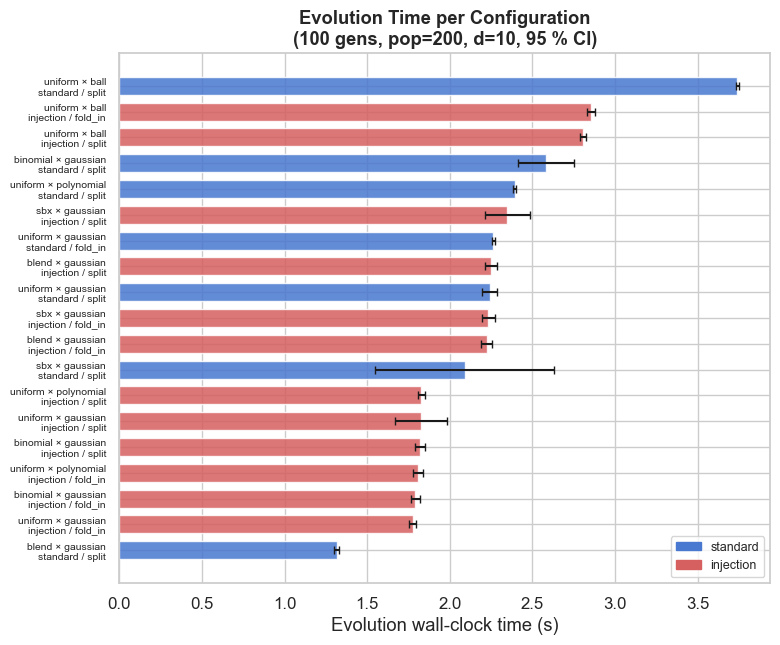

In [13]:
# Evolution wall-clock time per configuration
if "t_evo" in df.columns:
    time_agg = (
        df.groupby(["crossover", "mutation", "mode", "key_derivation"])
        .apply(lambda g: agg_ci(g, "t_evo"), include_groups=False)
        .reset_index()
    )
    time_agg["label"] = (
        time_agg["crossover"] + " × " + time_agg["mutation"]
        + "\n" + time_agg["mode"] + " / " + time_agg["key_derivation"]
    )
    time_agg = time_agg.sort_values("mean").reset_index(drop=True)

    colours = [PALETTE_MODE[m] for m in time_agg["mode"]]

    fig, ax = plt.subplots(figsize=(8, max(5, len(time_agg) * 0.35)))
    y = np.arange(len(time_agg))
    xerr_lo = time_agg["mean"] - time_agg["ci_lo"]
    xerr_hi = time_agg["ci_hi"] - time_agg["mean"]

    ax.barh(y, time_agg["mean"], xerr=[xerr_lo.clip(lower=0), xerr_hi.clip(lower=0)],
            color=colours, capsize=3, alpha=0.85, edgecolor="white", height=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(time_agg["label"], fontsize=7.5)
    ax.set_xlabel("Evolution wall-clock time (s)")
    ax.set_title("Evolution Time per Configuration\n(100 gens, pop=200, d=10, 95 % CI)",
                 fontweight="bold")

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=PALETTE_MODE[m], label=m) for m in ["standard", "injection"]]
    ax.legend(handles=legend_handles, loc="lower right", fontsize=9)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "fp_10_evolution_time.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No timing data found in runs")

## 13. Statistical Parity Test — Welch's t-test
For each (crossover × mutation) pair with both standard and injection runs,  
$H_0$: same mean best fitness. A p-value > 0.05 means we **cannot reject parity** (good).

In [14]:
# Welch's t-test: standard vs injection for each (crossover, mutation, key_derivation) group
ttest_rows = []
for (cx, mt, kd), grp in df.groupby(["crossover", "mutation", "key_derivation"]):
    std_vals = grp[grp["mode"] == "standard"]["best_fitness"].values
    inj_vals = grp[grp["mode"] == "injection"]["best_fitness"].values
    if len(std_vals) < 2 or len(inj_vals) < 2:
        continue
    t_stat, p_val = sp_stats.ttest_ind(std_vals, inj_vals, equal_var=False)
    ttest_rows.append({
        "crossover": cx,
        "mutation": mt,
        "key_derivation": kd,
        "mean_std": std_vals.mean(),
        "mean_inj": inj_vals.mean(),
        "gap": std_vals.mean() - inj_vals.mean(),
        "t_stat": t_stat,
        "p_value": p_val,
        "parity": "✅" if p_val > 0.05 else "❌",
    })

ttest_df = pd.DataFrame(ttest_rows)
if len(ttest_df):
    display(
        ttest_df.style
        .format({
            "mean_std": "{:.4f}", "mean_inj": "{:.4f}", "gap": "{:.6f}",
            "t_stat": "{:.4f}", "p_value": "{:.4f}",
        })
        .set_caption("Welch's t-test: standard vs injection (p > 0.05 → cannot reject parity)")
        .applymap(lambda v: "background-color: #d4edda" if v == "✅" else
                  ("background-color: #f8d7da" if v == "❌" else ""),
                  subset=["parity"])
    )
    n_pass = (ttest_df["parity"] == "✅").sum()
    print(f"\n{n_pass}/{len(ttest_df)} tests pass parity (p > 0.05)")
else:
    print("Not enough paired (standard, injection) data for t-tests")

/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_95963/1124103821.py:30: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "background-color: #d4edda" if v == "✅" else


,crossover,mutation,key_derivation,mean_std,mean_inj,gap,t_stat,p_value,parity
0,binomial,gaussian,split,-193.8560,-193.8558,-0.000191,-0.9666,0.3395,✅
1,blend,gaussian,split,-193.8567,-193.8567,0.000002,0.8503,0.3987,✅
2,sbx,gaussian,split,-193.8567,-193.8567,-0.000014,-1.3409,0.1855,✅
3,uniform,ball,split,-193.8550,-193.8551,0.000089,0.7707,0.4440,✅
4,uniform,gaussian,fold_in,-193.8567,-193.8567,-0.000004,-0.5920,0.5567,✅
5,uniform,gaussian,split,-193.8567,-193.8567,-0.000004,-0.5920,0.5567,✅
6,uniform,polynomial,split,-193.8563,-193.8562,-0.000087,-1.3194,0.1923,✅



7/7 tests pass parity (p > 0.05)


---
## Summary

| Section | What it shows |
|---------|---------------|
| §2 | Summary table with 95 % CI for every experiment |
| §3 | Crossover parity bar chart (std vs inj) |
| §4 | Mutation parity bar chart (std vs inj) |
| §5 | Key derivation parity bar chart (SPLIT vs FOLD) |
| §6 | Convergence curves — crossover (CI band) |
| §7 | Convergence curves — mutation (CI band) |
| §8 | Convergence curves — key derivation (CI band) |
| §9 | Δ best improvement dot-plot |
| §10 | Per-seed swarm+box distribution |
| §11 | Parity gap heatmap (crossover × mutation) |
| §12 | Evolution wall-clock time |
| §13 | Welch's t-test for statistical parity |

**Next steps:** Replace `Results_DAH02/fitness_parity/` with 30-seed data and re-run all cells.  The CI bands will tighten and the t-tests will gain statistical power.

> The analyses above already assume a shared starting population and include
evosax as a golden standard, so new data will plug seamlessly into the same
plots.